<center> 

## Data Science for Social Impact
# Homework Tuesday: Visualizing Dataframes + Debugging Conditionals and Iteration

Please complete this notebook by filling in the cells provided. The solved homework should be uploaded to Gradescope on Canvas.

Note: There is no autograder for tonight's homework. You will receive comments on your work from Avery tomorrow afternoon.

<center>
<img src="https://raw.githubusercontent.com/amandakube/Data118LectureImages/main/UChicago_DSI.png" alt="UC-DSI" width="300" height="100">
</center>


#### Deadline:

This assignment is due on **Tuesday at 11:30pm**.

Directly sharing answers is not okay, but discussing problems with eachother is encouraged!


In [ ]:
# Don't change this cell; just run it.

import numpy as np
import pandas as pd


from matplotlib import pyplot as plt
plt.style.use('fivethirtyeight')

# Sales Competition

A company has created a competition where all sales made by members of the sales team were tracked for the year of 2022. All members of the sales department have been divided into two teams: Team A and Team B. The team with the highest monetary value of total sales will win a \$500 bonus. Using the data from `sales.csv` and `teams.csv`, we want to calculate the total sales from each team and determine which team wins the competition.

**Question 1.**  Write code that creates a dataframe that shows the total value of sales made during 2022 for each salesperson. Assign to `person_totals`. Create an appropriate graph to show the distribution of `person_totals`.

In [ ]:
sales = pd.read_csv('sales.csv')
teams = pd.read_csv('teams.csv')

In [ ]:
person_totals = sales.groupby('Name')[['Sale']].sum()
person_totals

,Sale
Name,
A'Dericka Carr,829.72
Grey Harrington,1284.74
Jamar Adams,1099.65
Jazmin Arnold,1384.69
Khris Fletcher,1224.67
Maggie Zhou,689.82
Marshawn Williams,1004.75
Nathan Chitwood,584.87
Samantha Ruiz,984.77


**Question 2.**  Construct a dataframe called `team_totals` that shows the total monetary value of sales made for each team. Use an appropriate graph to depict this data. Which team won the competition?

In [ ]:
team_totals = pd.merge(person_totals, teams, left_index=True, right_on = 'Employee', how='outer').groupby('Team')[['Sale']].sum()
team_totals

,Sale
Team,
A,5263.47
B,4948.87


Team A won

The company is also interested in how individual salespersons performed for upcoming employee evaluations. They want to rank each sales person based on the total monetary value made from sales, as well as their average monetary value per sale.

**Question 3.**  Create a dataframe that includes the name of each person, the total number of sales they made, and the total monetary value of their sales in 2022. Add an additional column that ranks each person based on their total monetary value of sales. (ie the highest gets rank 1 and so on)

In [ ]:
sale_num = sales.groupby('Name')['Sale'].count()
person_totals['Number of Sales'] = sale_num
person_totals.sort_values('Sale', ascending=False, inplace=True)
person_totals['Sale Rank'] = np.arange(1,11)
person_totals = person_totals.reset_index()
person_totals

,Name,Sale,Number of Sales,Sale Rank,Average per Sale,Average Rank
0,Jazmin Arnold,1384.69,31,1,44.667419,3
1,Grey Harrington,1284.74,26,2,49.413077,1
2,Khris Fletcher,1224.67,33,3,37.111212,7
3,Some Ebo,1124.66,34,4,33.078235,8
4,Jamar Adams,1099.65,35,5,31.418571,9
5,Marshawn Williams,1004.75,25,6,40.190000,5
6,Samantha Ruiz,984.77,23,7,42.816087,4
7,A'Dericka Carr,829.72,28,8,29.632857,10
8,Maggie Zhou,689.82,18,9,38.323333,6
9,Nathan Chitwood,584.87,13,10,44.990000,2


**Question 4.**  Add an additional column that contains the average value per sale for each sales person. Use this value to rank all sales persons compared to each other. Add yet another column containing these ranks.

In [ ]:
person_totals['Average per Sale'] = person_totals['Sale']/person_totals['Number of Sales']
person_totals.sort_values('Average per Sale', ascending=False, inplace=True)
person_totals['Average Rank'] = np.arange(1,11)
person_totals

,Name,Sale,Number of Sales,Sale Rank,Average per Sale,Average Rank
1,Grey Harrington,1284.74,26,2,49.413077,1
9,Nathan Chitwood,584.87,13,10,44.990000,2
0,Jazmin Arnold,1384.69,31,1,44.667419,3
6,Samantha Ruiz,984.77,23,7,42.816087,4
5,Marshawn Williams,1004.75,25,6,40.190000,5
8,Maggie Zhou,689.82,18,9,38.323333,6
2,Khris Fletcher,1224.67,33,3,37.111212,7
3,Some Ebo,1124.66,34,4,33.078235,8
4,Jamar Adams,1099.65,35,5,31.418571,9
7,A'Dericka Carr,829.72,28,8,29.632857,10


**Question 5.**  Using the above dataframe, create a grouped bar chart (you may need to consult matplotlib's documentation) where each salesperson has 2 bars, one for total value of sales and one for average value of sales. What is one pro and one con of this way of depicting the data?

**Challenge:** Sort the salespeople along the x axis: 1) alphabetically, 2) by largest to smallest total value of sales, 3) by smallest to largest average values of sales.

Text(0, 0.5, 'Sales in USD')

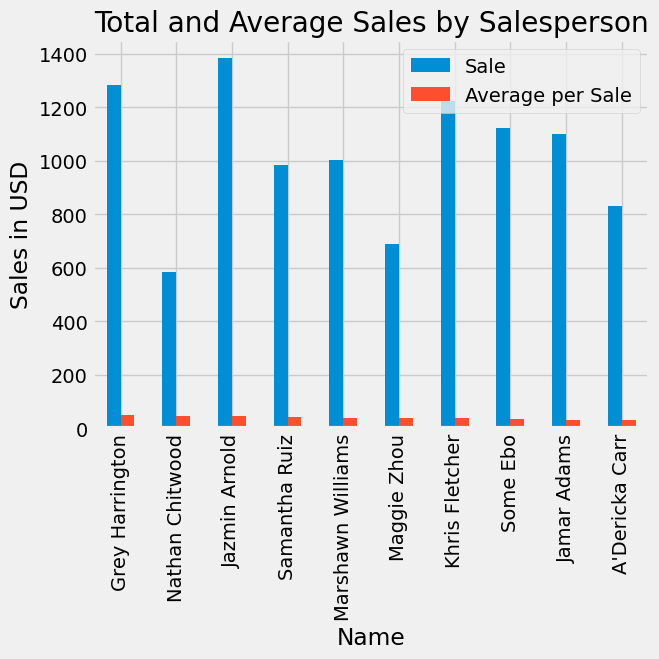

In [ ]:
totals_plot = person_totals[['Name','Sale','Average per Sale']]
totals_plot.plot(x='Name', kind='bar', stacked=False, title='Total and Average Sales by Salesperson')
plt.ylabel('Sales in USD')

Pro: Easily comparable
Con: Total sales is so large it dwarfs average sales

Text(0, 0.5, 'Sales in USD')

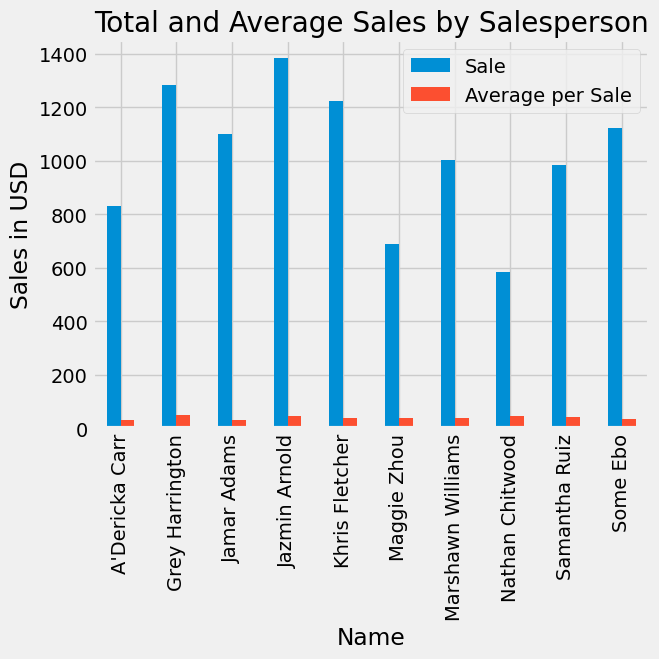

In [ ]:
totals_plot = person_totals[['Name','Sale','Average per Sale']].sort_values("Name")
totals_plot.plot(x='Name', kind='bar', stacked=False, title='Total and Average Sales by Salesperson')
plt.ylabel('Sales in USD')

Text(0, 0.5, 'Sales in USD')

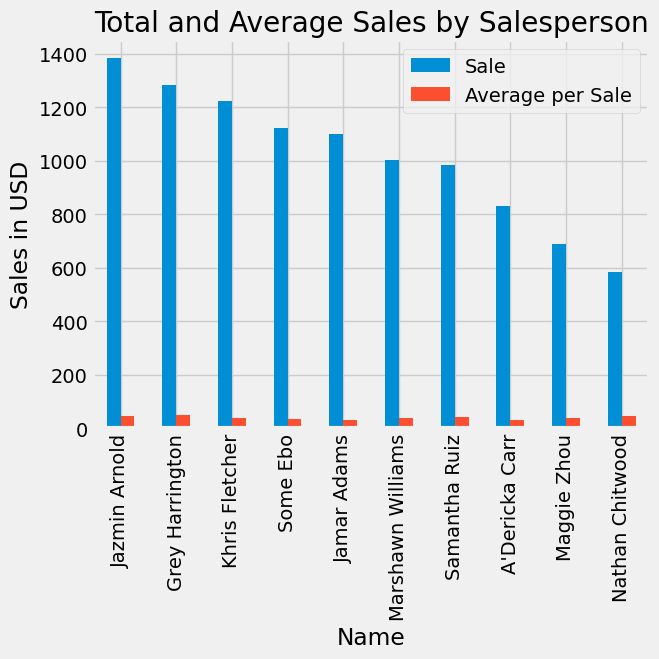

In [ ]:
totals_plot = person_totals[['Name','Sale','Average per Sale']].sort_values("Sale",ascending=False)
totals_plot.plot(x='Name', kind='bar', stacked=False, title='Total and Average Sales by Salesperson')
plt.ylabel('Sales in USD')

Text(0, 0.5, 'Sales in USD')

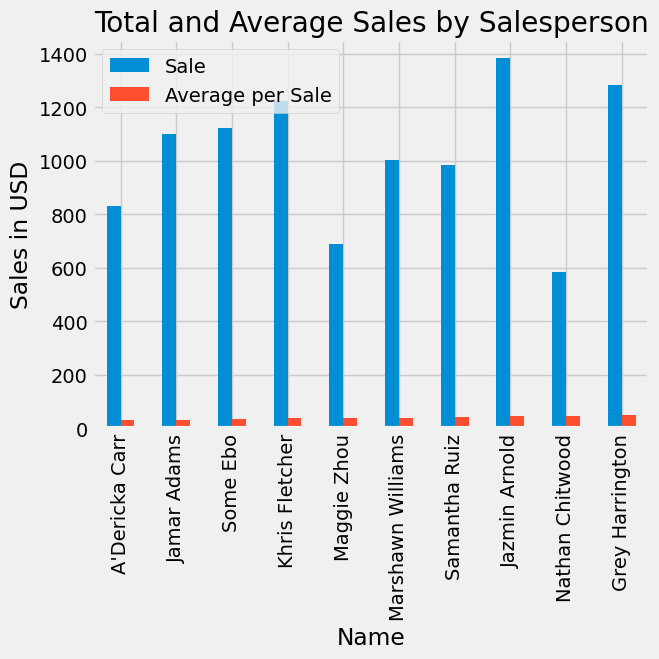

In [ ]:
totals_plot = person_totals[['Name','Sale','Average per Sale']].sort_values("Average per Sale")
totals_plot.plot(x='Name', kind='bar', stacked=False, title='Total and Average Sales by Salesperson')
plt.ylabel('Sales in USD')

# Sleep Health

This data comes from Kaggle with the following description:

### Dataset Overview:

The Sleep Health and Lifestyle Dataset comprises 400 rows and 13 columns, covering a wide range of variables related to sleep and daily habits. It includes details such as gender, age, occupation, sleep duration, quality of sleep, physical activity level, stress levels, BMI category, blood pressure, heart rate, daily steps, and the presence or absence of sleep disorders.

### Key Features of the Dataset:
Comprehensive Sleep Metrics: Explore sleep duration, quality, and factors influencing sleep patterns.

Lifestyle Factors: Analyze physical activity levels, stress levels, and BMI categories.

Cardiovascular Health: Examine blood pressure and heart rate measurements.

Sleep Disorder Analysis: Identify the occurrence of sleep disorders such as Insomnia and Sleep Apnea.

### Dataset Columns:

- Person ID: An identifier for each individual.
- Gender: The gender of the person (Male/Female).
- Age: The age of the person in years.
- Occupation: The occupation or profession of the person.
- Sleep Duration (hours): The number of hours the person sleeps per day.
- Quality of Sleep (scale: 1-10): A subjective rating of the quality of sleep, ranging from 1 to 10.
- Physical Activity Level (minutes/day): The number of minutes the person engages in physical activity daily.
- Stress Level (scale: 1-10): A subjective rating of the stress level experienced by the person, ranging from 1 to 10.
- BMI Category: The BMI category of the person (e.g., Underweight, Normal, Overweight).
- Blood Pressure (systolic/diastolic): The blood pressure measurement of the person, indicated as systolic pressure over diastolic pressure.
- Heart Rate (bpm): The resting heart rate of the person in beats per minute.
- Daily Steps: The number of steps the person takes per day.
- Sleep Disorder: The presence or absence of a sleep disorder in the person (None, Insomnia, Sleep Apnea).

#### Details about Sleep Disorder Column:
- None: The individual does not exhibit any specific sleep disorder.
- Insomnia: The individual experiences difficulty falling asleep or staying asleep, leading to inadequate or poor-quality sleep.
- Sleep Apnea: The individual suffers from pauses in breathing during sleep, resulting in disrupted sleep patterns and potential health risks."

In [ ]:
sleep_df = pd.read_csv('Sleep_health_dataset.csv')
sleep_df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


**Question 6.**  Use an appropriate graph to visualize the average quality of sleep by gender.

<Axes: title={'center': 'Average Quality of Sleep by Gender'}, xlabel='Gender', ylabel='1-10 self reported scale'>

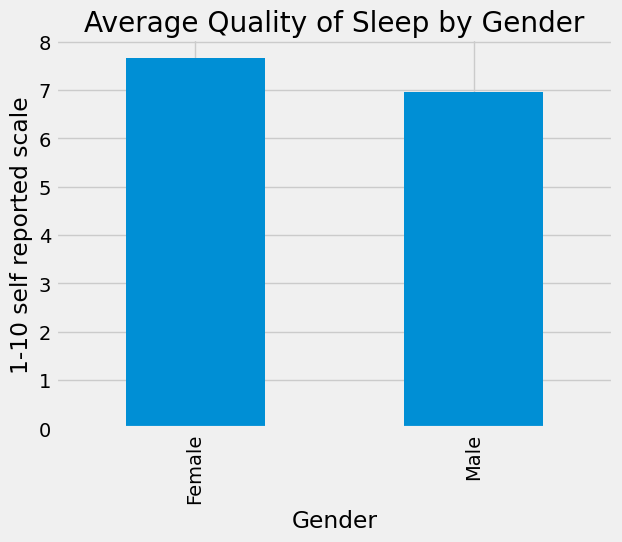

In [ ]:
sleep_df.groupby('Gender')['Quality of Sleep'].mean().plot.bar(title = 'Average Quality of Sleep by Gender', ylabel = '1-10 self reported scale')

**Question 7.** Use a histogram to plot sleep duration.
Experiment with the bins and decide what makes sense.

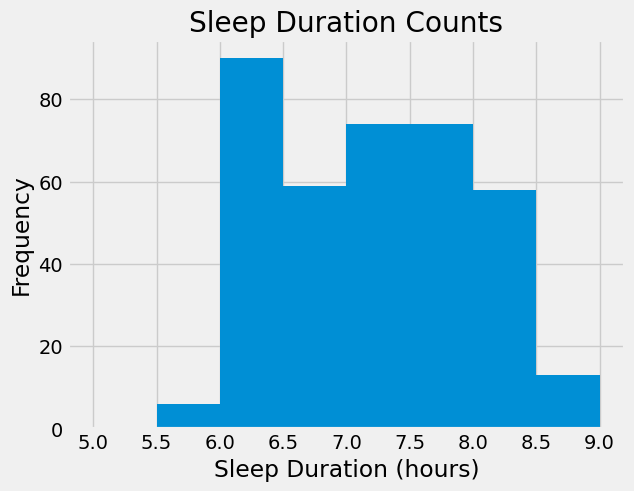

In [ ]:
half_hour = [5,5.5,6,6.5,7,7.5,8,8.5,9]

hour = [5,6,7,8,9]

quarter_hour = np.arange(5,9.25,.25)

plt.hist(sleep_df['Sleep Duration'], bins = half_hour)
plt.title('Sleep Duration Counts')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()


#note we decided bin ranges, so it is a good idea to ensure all of the data is contained in our visualization!
#we can find the max and min to make sure everything is accounted for
#sleep_df['Sleep Duration'].max()
#sleep_df['Sleep Duration'].min()

**Question 8.**  Use an appropriate graph to visualize sleep duration of those who have sleep apnea.

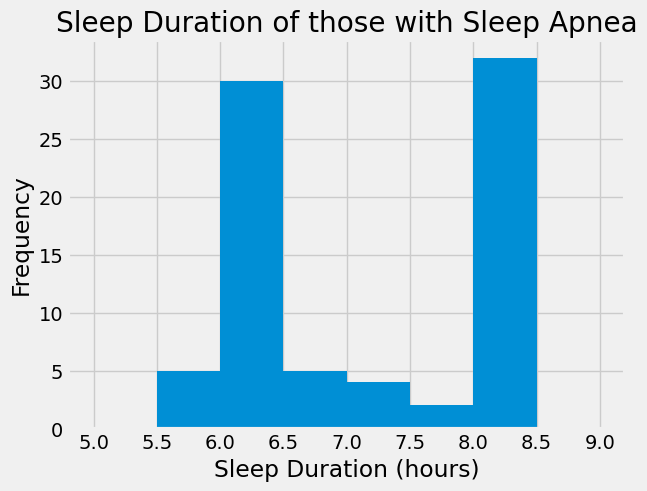

In [ ]:
sleep_disorder = sleep_df.groupby('Sleep Disorder')

only_sleep_apnea = sleep_disorder.get_group('Sleep Apnea')
only_sleep_apnea



plt.hist(only_sleep_apnea['Sleep Duration'], bins = half_hour)
plt.title('Sleep Duration of those with Sleep Apnea')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Frequency')
plt.show()

**Question 9.** Create an overlapping histogram comparing Sleep Duration for each Sleep Disorder Category (including NaN).




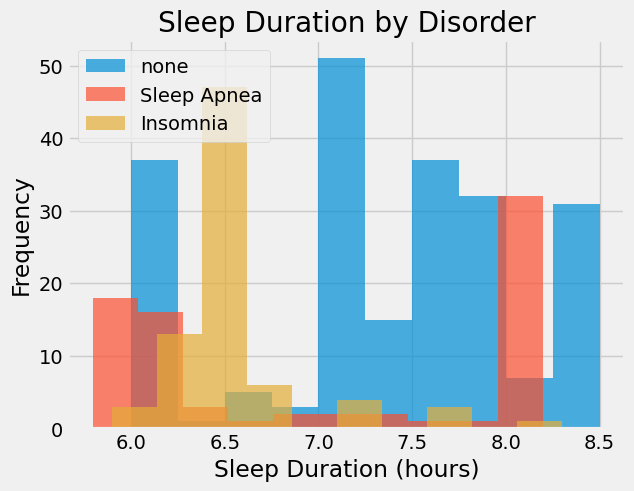

In [ ]:
plt.hist(sleep_df.loc[sleep_df['Sleep Disorder'].isna(),'Sleep Duration'],
         label='none', alpha = 0.7)
plt.hist(sleep_df.loc[sleep_df['Sleep Disorder'] == 'Sleep Apnea','Sleep Duration'],
         label='Sleep Apnea', alpha = 0.7)

plt.hist(sleep_df.loc[sleep_df['Sleep Disorder'] == 'Insomnia','Sleep Duration'],
         label='Insomnia', alpha = 0.7)

plt.legend(loc='upper left')
plt.title('Sleep Duration by Disorder')
plt.ylabel("Frequency")
plt.xlabel("Sleep Duration (hours)")
plt.show()

**Question 10.** Create a boxplot that shows the same information shown in your overlapping histogram above. Which plot is a better depiction of the information?

Text(0.5, 0, 'Sleep Disorder')

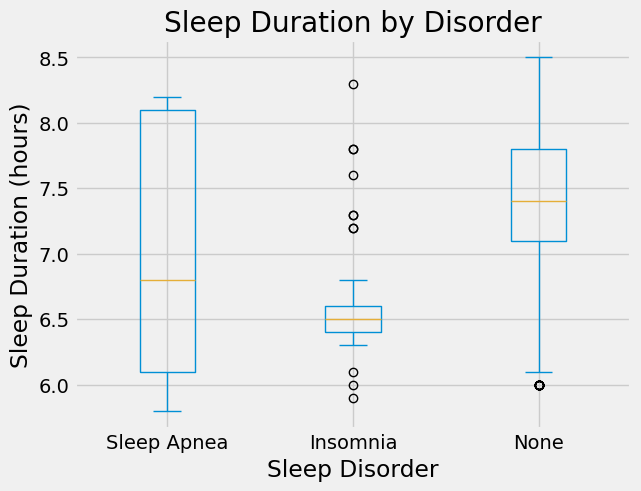

In [ ]:
df = pd.DataFrame({"Sleep Apnea": sleep_df.loc[sleep_df['Sleep Disorder'] == 'Sleep Apnea','Sleep Duration'],
                   "Insomnia": sleep_df.loc[sleep_df['Sleep Disorder'] == 'Insomnia','Sleep Duration'],
                   "None":sleep_df.loc[sleep_df['Sleep Disorder'].isna(),'Sleep Duration']})
df.plot(kind='box')
plt.title("Sleep Duration by Disorder")
plt.ylabel("Sleep Duration (hours)")
plt.xlabel("Sleep Disorder")

The boxplot is easier to read in this case

# Iteration and Conditionals - Debugging

For each of the following, edit my code so that it correctly answers the question.

**Question 11.** Print every multiple of 3 from 3 to 108 inclusive.




In [ ]:
for i in np.arange(3,109):
  if i % 3 == 0:
    print(i)

3
6
9
12
15
18
21
24
27
30
33
36
39
42
45
48
51
54
57
60
63
66
69
72
75
78
81
84
87
90
93
96
99
102
105
108


**Question 12.** Count the number of times a '4' appears as a digit in any number from 1 to 100000


In [ ]:
fcount = 0
for f in np.arange(1,100000):
  if '4' in str(f):
    for c in str(f):
      if c == "4":
        fcount = fcount + 1

print(fcount)

50000


**Question 13.** Count the number of words in `word_list` that end with 'ight'.

**Challenge:** Look at the code I use to get my list of words. Write comments on each line explaining what the lines do. You may need to search these functions and/or look at the website where the txt file lives.

In [ ]:
import requests
words = requests.get("https://raw.githubusercontent.com/dwyl/english-words/master/words.txt") # pulls in all of the text from this website which has a list of words
word_list = words.text.split("\n") # words.text gets you the text out of the words object so that we are now working with a string, then we use str.split() to split the string into a list and tell it to break at each newline
# the result is a list of words from that txt file
count = 0
for word in word_list:
  if len(word) >= 4:
    if word[-4:] == 'ight':
      #print(word)
      count = count + 1
print(count)

506
